**IMPORTING ALL THE NECESSARY LIBRARIES FOR THE EDA - Exploratory Data Analysis**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

c:\Users\ankit\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
## Load the Dataset

# !pip install kagglehub
# import kagglehub
# from kagglehub import KaggleDatasetAdapter
# file_path = ""

# telco_df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "blastchar/telco-customer-churn", file_path)

In [3]:
# Load the Dataset

telco_df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
telco_df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Dataset Overview**

In [4]:
print(f"Shape (rows, column) of Telco dataframe : {telco_df.shape}")

Shape (rows, column) of Telco dataframe : (7043, 21)


In [5]:
telco_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Missing Value Analysis**

In [6]:
telco_df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
(telco_df == ' ').sum()     #checking for blank data

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [8]:
telco_df['TotalCharges'] = pd.to_numeric(telco_df['TotalCharges'], errors='coerce')

# Checking for NaN data after converting the data to numeric from string in TotalCharges
# telco_df[telco_df['TotalCharges'].isna()]
telco_df.dropna(subset=['TotalCharges'], inplace = True)
telco_df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Checking the variables individually**

<Axes: xlabel='tenure', ylabel='Count'>

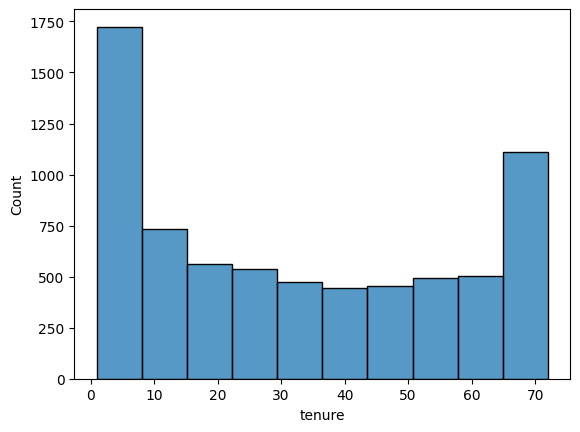

In [9]:
sns.histplot(telco_df['tenure'], bins = 10)

<Axes: xlabel='Contract', ylabel='count'>

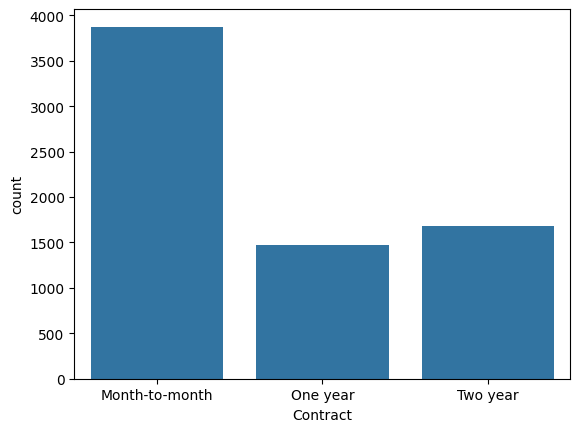

In [10]:
sns.countplot(data=telco_df, x = 'Contract')

**Target Varaible Analysis - Churn column**

In [11]:
telco_df['Churn'].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

<Axes: xlabel='Churn', ylabel='count'>

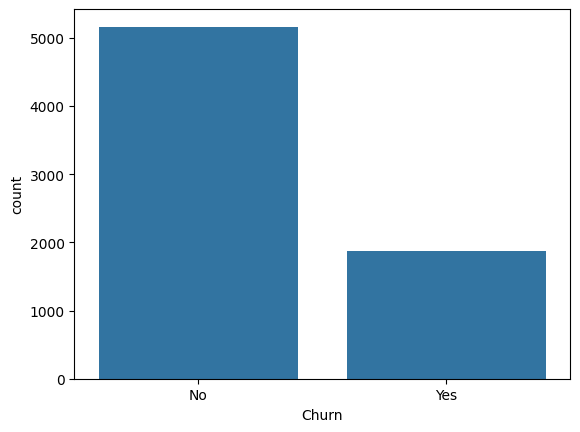

In [12]:
sns.countplot(data=telco_df, x = 'Churn')

**Comparing the data with Churn variable**

<Axes: xlabel='MonthlyCharges', ylabel='Churn'>

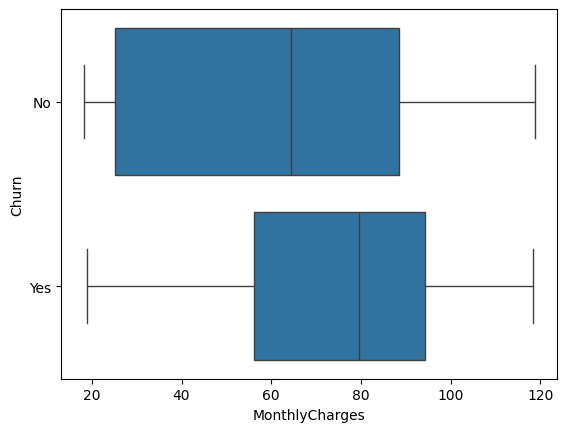

In [13]:
sns.boxplot(x=telco_df['MonthlyCharges'], y = telco_df['Churn'])

In [14]:
pd.crosstab(telco_df['Contract'], telco_df['Churn'], normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


<Axes: xlabel='Contract', ylabel='count'>

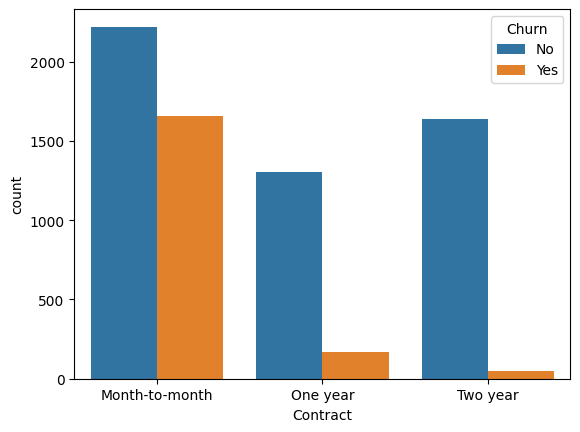

In [15]:
sns.countplot(x='Contract',hue='Churn',data=telco_df)

<Axes: xlabel='TechSupport', ylabel='count'>

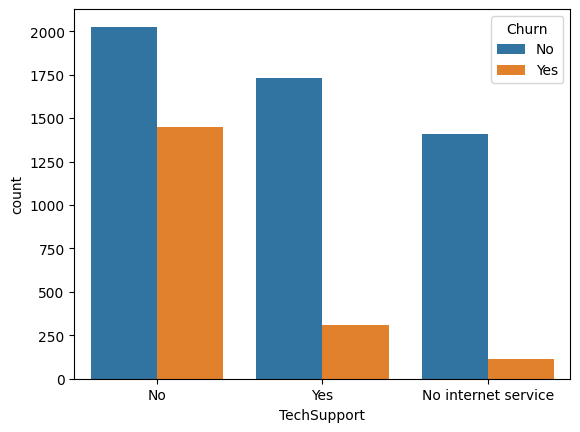

In [16]:
sns.countplot(data=telco_df, x='TechSupport', hue='Churn')

<Axes: xlabel='tenure', ylabel='Churn'>

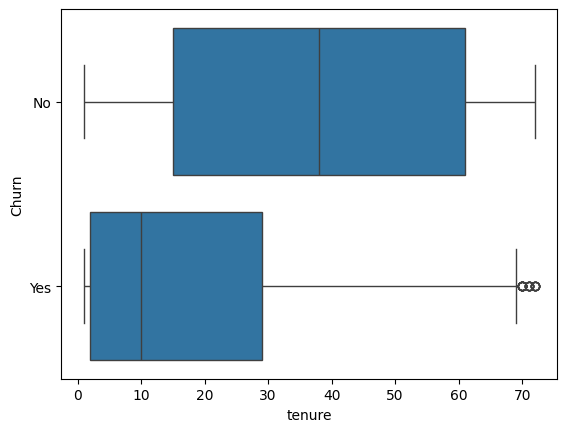

In [17]:
sns.boxplot(data=telco_df, x='tenure', y='Churn')

**Multivariate Analysis**

<Axes: >

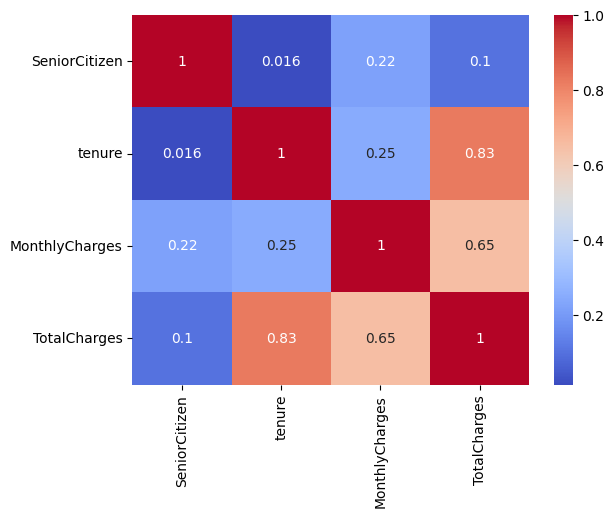

In [18]:
sns.heatmap(telco_df.corr(numeric_only=True), annot=True, cmap='coolwarm')

**Feature Engineering**

In [19]:
# max tenure count
# telco_df['tenure'].max()

In [20]:
t_group = [0, 12, 24, 48, 72]
labels = ['New', 'Growing', 'Established', 'Loyal']

telco_df['TenureGroup'] = pd.cut(telco_df['tenure'], bins = t_group, labels=labels)

In [21]:
telco_df['TenureGroup']

0               New
1       Established
2               New
3       Established
4               New
           ...     
7038        Growing
7039          Loyal
7040            New
7041            New
7042          Loyal
Name: TenureGroup, Length: 7032, dtype: category
Categories (4, str): ['New' < 'Growing' < 'Established' < 'Loyal']

In [22]:
#Customer's lifetime subscription charge
telco_df['TotalSubsCharge'] = (telco_df['MonthlyCharges'] * telco_df['tenure'])
telco_df['TotalSubsCharge']

0         29.85
1       1936.30
2        107.70
3       1903.50
4        141.40
         ...   
7038    2035.20
7039    7430.40
7040     325.60
7041     297.60
7042    6972.90
Name: TotalSubsCharge, Length: 7032, dtype: float64

In [23]:
# loss revenue
total_churn_lost = telco_df[telco_df['Churn'] == 'Yes']['MonthlyCharges'].sum()
total_churn_lost

139130.85

**Statistical Testing**

*Chi-Test*

In [24]:
from scipy.stats import chi2_contingency

categorial_features = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

for feature in categorial_features:
    contingency = pd.crosstab(telco_df[feature], telco_df['Churn'])

    chi2, p, _, _ = chi2_contingency(contingency)

    if p <0.05:
        print(f"P value : {p:.2f}\nThere is a statistical significant relationship between {feature} and Churn\n")
    else:
        print(f"The {feature} and Churn are independent of each other")

P value : 0.00
There is a statistical significant relationship between OnlineSecurity and Churn

P value : 0.00
There is a statistical significant relationship between OnlineBackup and Churn

P value : 0.00
There is a statistical significant relationship between DeviceProtection and Churn

P value : 0.00
There is a statistical significant relationship between TechSupport and Churn

P value : 0.00
There is a statistical significant relationship between StreamingTV and Churn

P value : 0.00
There is a statistical significant relationship between StreamingMovies and Churn

P value : 0.00
There is a statistical significant relationship between Contract and Churn

P value : 0.00
There is a statistical significant relationship between PaperlessBilling and Churn

P value : 0.00
There is a statistical significant relationship between PaymentMethod and Churn



*Independent T-Test*

In [25]:
from scipy.stats import ttest_ind

churned_monthly = telco_df.loc[telco_df['Churn'] == 'Yes', 'MonthlyCharges']

retained_monthly = telco_df.loc[telco_df['Churn'] == 'No', 'MonthlyCharges']

t_stats, p_val = ttest_ind(churned_monthly, retained_monthly, equal_var=False)

if p < 0.001:
    print("Reject H0: Monthly charges differ significantly.")
else:
    print("Fail to reject H0.")

Reject H0: Monthly charges differ significantly.


In [26]:
churned_tenure = telco_df.loc[telco_df['Churn'] == 'Yes', 'tenure']

retained_tenure = telco_df.loc[telco_df['Churn'] == 'No', 'tenure']

t_stats, p_tenure = ttest_ind(churned_tenure, retained_tenure, equal_var=False)

if p < 0.001:
    print("Reject H0: Tenure differ significantly.")
else:
    print("Fail to reject H0.")

Reject H0: Tenure differ significantly.


| Variable       | Test       | p-value | Significant? | Business Insight                      |
| -------------- | ---------- | ------- | ------------ | ------------------------------------- |
| Contract       | Chi-Square | <0.001  | Yes          | Contract affects churn                |
| PaymentMethod  | Chi-Square | <0.001  | Yes          | Payment method impacts churn          |
| Tenure         | T-Test     | <0.001  | Yes          | Churned customers have shorter tenure |
| MonthlyCharges | T-Test     | <0.001  | Yes          | Charges differ across churn groups    |


**============================================================================================**

**Saving the updated telco data to csv**

In [ ]:
# telco_df.to_csv("Updated_Churn_Analysis_Dataset.csv", index=False)

**Pushing the Updated dataframe to the PostgreSQL**

In [23]:
from sqlalchemy import create_engine

# PostgreSQL credentials
username = "postgres"
password = "1234"
host = "127.0.0.1"
port = "5432"
database = "telco_db"

# Create engine
engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

print("Connection successful!")

Connection successful!


In [29]:
# telco_df.head(5)

In [29]:
telco_df.to_sql(
    name = 'telco_churn',
    con = engine,
    if_exists='replace', #'replace',        #if re-uploading, use append instead
    index=False
)
print("Data upload successfully")

Data upload successfully


In [30]:
query = """
SELECT COUNT(*)  AS total_rows
FROM telco_churn;
"""

result = pd.read_sql(query, engine)

print(result)

   total_rows
0        7032


**Creating views**

In [46]:
from sqlalchemy import text

query = """
CREATE OR REPLACE VIEW churn_summary AS
SELECT
    COUNT(*) AS total_customers,
   
    ROUND(
    (100 *
        SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END):: NUMERIC
        / COUNT(*)
    ), 2)
    AS churn_rate,

    ROUND(
        SUM("MonthlyCharges")::NUMERIC,
        2
    ) AS monthly_revenue,

    ROUND(
        SUM(
            CASE
                WHEN "Churn" = 'Yes'
                THEN "MonthlyCharges"
                ELSE 0
            END
        )::NUMERIC,
        2
    ) AS revenue_lost

FROM telco_churn;
"""

with engine.begin() as conn:
    conn.execute(text(query))

print("Churn_summary View created successfully!")

Churn_summary View created successfully!


In [32]:
query = """
CREATE OR REPLACE VIEW churn_by_contract AS
SELECT
    "Contract",
    COUNT(*) AS customers,
    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN "Churn" = 'Yes'
                THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS churn_rate
FROM telco_churn
GROUP BY "Contract";
"""

with engine.begin() as conn:
    conn.execute(text(query))

print("churn_by_contract view created successfully!")

churn_by_contract view created successfully!


In [33]:
query = '''
CREATE OR REPLACE VIEW churn_by_internet AS
SELECT
    "InternetService",
    COUNT(*) AS customers,
    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN "Churn" = 'Yes'
                THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS churn_rate
FROM telco_churn
GROUP BY "InternetService";
'''

with engine.begin() as conn:
    conn.execute(text(query))

print('churn_by_internet view created successfully!')

churn_by_internet view created successfully!


In [34]:
query = """
CREATE OR REPLACE VIEW revenue_by_contract AS
SELECT
    "Contract",
    ROUND(SUM("TotalCharges"):: NUMERIC, 2) AS revenue
FROM telco_churn
GROUP BY "Contract"
ORDER BY revenue DESC;
"""

with engine.begin() as conn:
    conn.execute(text(query))

print("revenue_by_contract view created successfully!")

revenue_by_contract view created successfully!


In [35]:
query = """
CREATE OR REPLACE VIEW churn_by_payment AS
SELECT
    "PaymentMethod",
    COUNT(*) AS customers,
    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN "Churn" = 'Yes'
                THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS churn_rate
FROM telco_churn
GROUP BY "PaymentMethod"
ORDER BY churn_rate DESC;
"""

with engine.begin() as conn:
    conn.execute(text(query))

print("churn_by_payment view created successfully!")

churn_by_payment view created successfully!


In [36]:
query = """
CREATE OR REPLACE VIEW customer_segments AS
SELECT
    "TenureGroup",
    COUNT(*) AS customers,

    ROUND(
        AVG("MonthlyCharges")::NUMERIC,
        2
    ) AS avg_monthly_charge,

    ROUND(
        SUM("TotalCharges")::NUMERIC,
        2
    ) AS revenue

FROM telco_churn
GROUP BY "TenureGroup";
"""

with engine.begin() as conn:
    conn.execute(text(query))

print("customer_segments view created successfully!")

customer_segments view created successfully!
